# LSTM (Long Short-Term Memory)

Implementar un modelo usando LSTM (secuencias): dataset de series temporales (p. ej. precios, sensor data) o texto secuencial (modelado de lenguaje char-level o word-level).



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.2201 - mae: 0.4066 - val_loss: 0.0288 - val_mae: 0.1426
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0092 - mae: 0.0736 - val_loss: 0.0031 - val_mae: 0.0488
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - mae: 0.0301 - val_loss: 5.1676e-04 - val_mae: 0.0177
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3.6678e-04 - mae: 0.0153 - val_loss: 2.1406e-04 - val_mae: 0.0120
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3657e-04 - mae: 0.0093 - val_loss: 8.5707e-05 - val_mae: 0.0071
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 5.2916e-05 - mae: 0.0053 - val_loss: 3.2248e-05 - val_mae: 0.0041
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 2.3631e-05 - mae: 0.0034 - val_loss: 1.8568e-05 - val_mae: 0.0029
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 1.4900e-05 - mae: 0.0027 - val_loss: 1.1379e-05 - val_mae: 0.0022
Epoch 9/10
24/24 ━━━

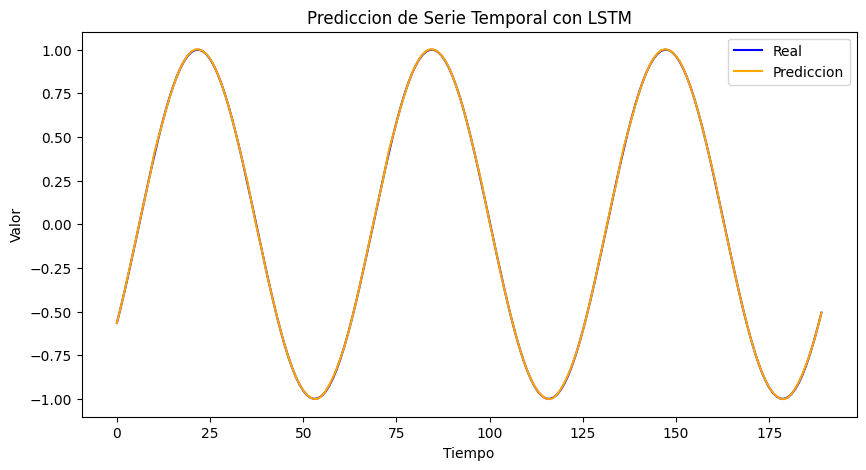

Analisis de los mayores errores cometidos:
----------------------------------------
Indice: 134 | Valor Real: 0.2442 | Prediccion: 0.2366 | Error Absoluto: 0.0076
Indice: 35 | Valor Real: 0.2362 | Prediccion: 0.2451 | Error Absoluto: 0.0090
Indice: 136 | Valor Real: 0.4322 | Prediccion: 0.4428 | Error Absoluto: 0.0106
Indice: 73 | Valor Real: 0.4112 | Prediccion: 0.4249 | Error Absoluto: 0.0137
Indice: 10 | Valor Real: 0.3900 | Prediccion: 0.4043 | Error Absoluto: 0.0142


In [2]:
# SEMANA 4 - LSTM Y SERIES TEMPORALES
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# GENERANDO DATOS DE PRUEBA (SERIE TEMPORAL)
sin_wave = np.sin(np.linspace(0, 100, 1000))

# CREAR SECUENCIAS PARA EL ENTRENAMIENTO
def create_sequences(data, seq_length):
    X, Y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        Y.append(data[i+seq_length])
    return np.array(X), np.array(Y)

seq_length = 50
X, Y = create_sequences(sin_wave, seq_length)

# AJUSTAR EMISION DE DIMENSIONES PARA LSTM (samples, timesteps, features)
X = np.expand_dims(X, axis=-1)

# DIVISION DE ENTRENAMIENTO Y TEST
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# MODELO LSTM PARA SERIES TEMPORALES
model = Sequential([
    LSTM(64, input_shape=(seq_length, 1), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()
model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=10, batch_size=32)

# EVALUACION DEL MODELO
loss, mae = model.evaluate(X_test, Y_test)
print(f'Loss (MSE): {loss:.4f}, MAE: {mae:.4f}')

# PREDICCIONES
Y_pred = model.predict(X_test)

# GRAFICAR RESULTADOS
plt.figure(figsize=(10, 5))
plt.plot(Y_test, label='Real', color='blue')
plt.plot(Y_pred, label='Prediccion', color='orange')
plt.title('Prediccion de Serie Temporal con LSTM')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.show()

# ANALISIS DE ERRORES EN LAS PREDICCIONES
errors = np.abs(Y_test - Y_pred.flatten())
max_error_indices = np.argsort(errors)[-5:]

print("Analisis de los mayores errores cometidos:")
print("-" * 40)
for idx in max_error_indices:
    print(f"Indice: {idx} | Valor Real: {Y_test[idx]:.4f} | Prediccion: {Y_pred[idx][0]:.4f} | Error Absoluto: {errors[idx]:.4f}")

## Conclusiones.

El rendimiento del modelo es exclente, estpo se ve por el analisis de la gráfica. La línea azul (Real) y la línea naranja (Predicción) se solapan casi a la perfección a lo largo de todo el eje temporal. El modelo ha capturado con total precisión la naturaleza periódica y la amplitud de la serie temporal.

El modelo LSTM está perfectamente entrenado. No muestra signos de overfitting ni de underfitting, por lo tanto no se requiere entrenamiento adicional.